# SpikeTransDVG: the assembled grounding architecture

Four frozen forks, one model. Events in, a referring expression in, one box out, spiking
end to end.

```
events (T,B,2,480,640)                      caption (B,L)
        |                                         |
  EventVisionEncoder                      SpikeLMTextEncoder
  Meta-SpikeFormer / SDTv2                SpikeLM BERT, roberta-base init
        |  s4 / s8 / s16b membranes              |  (B,L,256) tokens
        +------------> CrossModalFusion <--------+
                       CMSF spiking cross-attention, per scale
                                |
                          SpikingPAN neck
                          SpikeYOLO MS_ConvBlock / MS_StandardConv
                                |
                          SpikeDetect head
                          SpikeYOLO, anchor-free, DFL reg_max=16
                                |
                       boxes (xyxy px) + score
```

Nothing in `repositories/` is edited. Every component is built through its own
constructor and reached through `utils/forks.py`; what this project adds is the neck, the
wiring, and two initialisation fixes that the components need in order to work together
at all -- section 3 is about those, and both were found by measurement, not by reading.

Order of business:

1. **Check the parts load** and see what each fork contributes.
2. **Build the model** and account for every parameter.
3. **The two silent killers** -- an I-LIF that never fires, and a cross-attention that
   emits exactly zero. Both produce a running model with no error message.
4. **A real Talk2Event sample** at native 480x640: shapes, anchors, memory, timing.
5. **Does the caption actually matter?** The question the whole design exists to answer.
6. **Can it learn?** Single-sample overfit.
7. **Cost knobs** worth knowing before a training run.

In [1]:
from __future__ import annotations

import gc
import time
import warnings
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.ops import box_iou

from spiketrandvg.datasets.events_voxel_cube import T_STEPS, talk2event_cube
from spiketrandvg.datasets.talk2event_dataset import CLASSES, Talk2EventDataset
from spiketrandvg.models.grounding_loss import GroundingDetectionLoss
from spiketrandvg.models.grounding_model import DEFAULT_TAPS, SpikeTransDVG
from spiketrandvg.models.text_encoder import MAX_TEXT_LEN, build_tokenizer
from spiketrandvg.utils import forks

for msg in ("Using a non-tuple sequence", "torch.meshgrid", "IProgress not found",
            "Importing from timm.models.layers", "Importing from timm.models.registry"):
    warnings.filterwarnings("ignore", message=f".*{msg}.*")

import contextlib
import io
import transformers

transformers.logging.set_verbosity_error()


@contextlib.contextmanager
def quiet():
    # silence the forks' load reports so the measurement tables stay readable
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VISION_CKPT = forks.WS / "spiketrandvg" / "ckpts" / "spikeformer_v2_weights" / "55M_kd.pth"
torch.manual_seed(0)

print(f"device {DEVICE} | vision T {T_STEPS} | max text len {MAX_TEXT_LEN}")
print(f"vision checkpoint present: {VISION_CKPT.exists()}")
print("forks:", forks.fork_status())

/home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda | vision T 5 | max text len 80
vision checkpoint present: True
forks: {'sdt2': 'ok', 'spikeyolo': 'ok', 'spikelm': 'ok', 'talk2event': 'ok', 'sfod': 'ok', 'e3dsnn': 'ok', 'cmsf': 'ok'}


## 1. What each fork contributes

Four repositories, four roles. The loaders in `utils/forks.py` execute single files under
unique aliases rather than putting the repos on `sys.path` -- they all define
generically-named top-level modules (`models.py`, `lib/`, `utils/`) that would otherwise
collide with each other and with this package.

Two of these loads need more than an alias. SpikeYOLO's head imports
`ultralytics.utils.tal`, and importing that package for real runs the fork's
`__init__.py`, which builds the YOLO/SAM machinery and writes to `~/.config`; so the
import is stubbed and the two functions actually needed -- `make_anchors`, `dist2bbox`,
both pure torch -- are loaded from `tal.py` in isolation and rebound on the module object.
CMSF does `from lib.CPG import ...`, so its `lib/` is registered under that generic name
for the duration of the import and removed afterwards.

In [2]:
sy = forks.load_spikeyolo()
cmsf = forks.load_cmsf()

print("SpikeYOLO  ->", ", ".join(sorted(k for k in vars(sy) if not k.startswith("_"))))
print()
print("CMSF       ->", ", ".join(sorted(k for k in vars(cmsf) if not k.startswith("_"))))
print()
import sys
print("generic names kept out of sys.modules:",
      {n: (n in sys.modules) for n in ("lib", "spiking", "models", "ultralytics.utils.tal")})
print("make_anchors is the real one:", sy.make_anchors.__module__, "->", callable(sy.make_anchors))

SpikeYOLO  -> MS_AllConvBlock, MS_ConvBlock, MS_DownSampling, MS_StandardConv, MultiSpike4, SpikeConv, SpikeConvWithoutBN, SpikeDFL, SpikeDetect, SpikeSPPF, dist2bbox, make_anchors, mem_update

CMSF       -> Dynamic_Threshold_LIFNode, QK_Block, RepeatTextEncoder, SCA_Block, SpikingCrossAttention, SpikingQKAttention, Spiking_GFNN

generic names kept out of sys.modules: {'lib': False, 'spiking': False, 'models': False, 'ultralytics.utils.tal': True}
make_anchors is the real one: spikeyolo_tal.tal -> True


The neuron each fork brings is different, and the differences matter downstream:

* **SpikeYOLO** `mem_update` -- integer LIF, `round(clamp(v, 0, 4))`, spikes in
  `{0,1,2,3,4}`, stateless across calls (its membrane lives inside one forward).
  **Fires only above 0.5.**
* **CMSF** `Dynamic_Threshold_LIFNode` -- spikingjelly `MultiStepLIFNode` with a learnable
  threshold, binary spikes, membrane persists across calls, so it must be reset.
* **SpikeLM** `ElasticBiSpiking` -- ternary `{-alpha, 0, +alpha}` with alpha calibrated
  lazily from the first forward pass.

Everything is constructed with `backend='cupy'` hard-coded in the forks. `cupy` is only
touched at forward time, so `forks.allow_cupy_construction()` lets construction through
and `forks.use_torch_backend()` switches the neurons over.

In [3]:
x = torch.linspace(-1.5, 5.5, 15)
ilif = sy.mem_update()
print("SpikeYOLO integer-LIF response (single step):")
print("  input ", " ".join(f"{v:5.2f}" for v in x))
print("  output", " ".join(f"{v:5.2f}" for v in ilif(x[None])[0]))
print("\n  -> everything below 0.5 emits nothing. Any stage feeding this neuron must")
print("     deliver values of order 1, or the map goes dead with no error.")

SpikeYOLO integer-LIF response (single step):
  input  -1.50 -1.00 -0.50  0.00  0.50  1.00  1.50  2.00  2.50  3.00  3.50  4.00  4.50  5.00  5.50
  output  0.00  0.00  0.00  0.00  0.00  1.00  2.00  2.00  2.00  3.00  4.00  4.00  4.00  4.00  4.00

  -> everything below 0.5 emits nothing. Any stage feeding this neuron must
     deliver values of order 1, or the map goes dead with no error.


## 2. Build the model, and account for the parameters

`num_classes=1` is the grounding formulation: the caption already selects the object
through fusion, so the head's single score means "this is the referred object" rather than
"this is a car". `num_classes=8` turns the same model into language-conditioned detection
over the Talk2Event classes.

The pyramid is **strides 4/8/16, not the usual 8/16/32**. Talk2Event boxes are small --
median ~62x66 px at 480x640, smallest under 10 px -- so a stride-32 level would be 15x20
cells resolving nothing that stride 16 does not, while stride 4 is what gives the smallest
objects any cells at all. DFL with `reg_max=16` bounds each side at 15 cells, i.e. 240 px
at stride 16, so boxes up to 480 px are still representable.

In [4]:
model = SpikeTransDVG(
    num_classes=1,
    d_model=256,
    taps=DEFAULT_TAPS,
    T=T_STEPS,
    vision_ckpt=str(VISION_CKPT) if VISION_CKPT.exists() else None,
    freeze_vision=True,          # backbone under no_grad: 21.7 GiB instead of an OOM
    text_donor="roberta-base",
).to(DEVICE)

tot = sum(p.numel() for p in model.parameters())
tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\ntotal {tot/1e6:.1f}M parameters, {tr/1e6:.1f}M trainable\n")
rows = [("vision (Meta-SpikeFormer)", model.vision), ("text (SpikeLM BERT)", model.text),
        ("fusion (CMSF x-attn)", model.fusion), ("neck (SpikeYOLO PAN)", model.neck),
        ("head (SpikeDetect)", model.head)]
print(f"{'stage':28s} {'params':>10s} {'trainable':>10s}")
for name, mod in rows:
    p = sum(q.numel() for q in mod.parameters())
    t = sum(q.numel() for q in mod.parameters() if q.requires_grad)
    print(f"{name:28s} {p/1e6:9.1f}M {t/1e6:9.1f}M")
print(f"\ntaps {model.taps} at strides {model.strides}")
print(f"fused scales: {model.fusion.fuse}")
print(f"head: nc={model.head.nc}, reg_max={model.head.reg_max}, "
      f"outputs/anchor={model.head.no}, stride buffer {model.head.stride.tolist()}")

[event_encoder] /home/karthik/Desktop/PhD/talk2events_research/spiketrandvg/ckpts/spikeformer_v2_weights/55M_kd.pth: loaded 823/827 tensors (missing 0, unexpected 4), stem 3ch -> 2ch


[text_encoder] initialised from 'roberta-base': loaded 197 tensors (2 converted), 457 SpikeLM-specific params kept at init
    embeddings.position_embeddings.weight: (514, 768) -> (512, 768) (dropped ids 0,1)
    embeddings.token_type_embeddings.weight: (1, 768) -> (2, 768) (segment replicated)

total 194.8M parameters, 140.1M trainable

stage                            params  trainable
vision (Meta-SpikeFormer)         54.7M       0.0M
text (SpikeLM BERT)              124.3M     124.3M
fusion (CMSF x-attn)               2.3M       2.3M
neck (SpikeYOLO PAN)               9.5M       9.5M
head (SpikeDetect)                 4.1M       4.1M

taps ('s4', 's8', 's16b') at strides (4, 8, 16)
fused scales: ('s4', 's8', 's16b')
head: nc=1, reg_max=16, outputs/anchor=65, stride buffer [4.0, 8.0, 16.0]


## 3. Two initialisation failures that produce no error

Both of these were found by measuring, not by reading the code, and both leave a model
that runs, trains, reports falling loss, and is quietly broken.

### 3a. The tapped features never reach the integer-LIF's threshold

`EventVisionEncoder` returns the backbone's residual stream -- membrane potentials, by
design, so the consumer chooses its own neuron. But SpikeYOLO's `mem_update` fires only
above 0.5, and those membranes do not arrive at that scale. Inside SpikeYOLO's own network
every I-LIF is fed a BatchNorm output, which is exactly the precondition a tap breaks.

`CrossModalFusion` therefore puts a `tap_norm` BatchNorm on each tap before the lateral
conv. Below: the tap distribution, and what the neuron does with and without it.

In [5]:
probe_cube = (torch.rand(T_STEPS, 1, 2, 160, 224, device=DEVICE) * 4).round()
model.eval()
with torch.no_grad():
    model.reset()
    maps = model.vision(probe_cube)

print(f"{'tap':6s} {'shape':>22s} {'std':>8s} {'|max|':>8s} {'I-LIF fires (raw)':>19s} {'(after tap_norm)':>18s}")
model.train()   # BatchNorm in train mode uses batch statistics
for name, v in maps.items():
    T_, B_, C_, H_, W_ = v.shape
    raw = sy.mem_update()(v)
    normed = model.fusion.tap_norm[name](v.flatten(0, 1)).reshape(T_, B_, C_, H_, W_)
    fired = sy.mem_update()(normed)
    print(f"{name:6s} {str(tuple(v.shape)):>22s} {v.std():8.4f} {v.abs().max():8.3f}"
          f" {(raw != 0).float().mean():18.3%} {(fired != 0).float().mean():17.3%}")
print("\nA randomly-initialised backbone is worse still: its residual stream is nearly")
print("constant per channel, and every tap collapses to exactly zero without tap_norm.")

tap                     shape      std    |max|   I-LIF fires (raw)   (after tap_norm)
s4        (5, 1, 128, 40, 56)   1.2160    7.363            79.114%           27.580%
s8        (5, 1, 256, 20, 28)   1.3682   10.138            75.237%           27.583%
s16b      (5, 1, 640, 10, 14)   2.3330   24.656            72.670%           24.554%

A randomly-initialised backbone is worse still: its residual stream is nearly
constant per channel, and every tap collapses to exactly zero without tap_norm.


### 3b. CMSF's cross-attention emits exactly zero at PyTorch's default init

This is the more consequential one. `SpikingCrossAttention` computes
`(q @ (k^T v)) * 0.125` and then thresholds at 0.5 -- so the raw spike-count product must
reach **4** before a single output spike appears. With the q/k/v BatchNorms at the default
gain of 1.0 those neurons fire at well under 1%, the product never approaches 4, and the
branch returns zero. `SCA_Block` is `x + attn(x, y, y)`, so it collapses to `x`: the model
detects objects and **ignores the caption entirely**, with no error and a perfectly
healthy-looking loss curve.

The fix is the standard threshold-dependent BN argument (tdBN, Zheng et al. AAAI 2021): a
spiking layer's normaliser has to be scaled to its neuron's threshold, not left at the ANN
default. `attn_bn_gain=3.0` is the smallest gain that makes the branch live, which
preserves the activation sparsity an SNN exists for. It is an ordinary BatchNorm weight,
so training can move it.

The sweep below rebuilds the model at several gains, calibrates BatchNorm, and measures
both the firing rate and whether the output responds to the caption at all.

In [6]:
tok = build_tokenizer()
CAPS = ["the car on the far left. not mentioned",
        "the pedestrian crossing the road. not mentioned",
        "a white truck parked near the building. not mentioned",
        "the cyclist moving right. not mentioned"]

def encode(caps):
    b = tok(caps, padding="max_length", truncation=True,
            max_length=MAX_TEXT_LEN, return_tensors="pt").to(DEVICE)
    return b["input_ids"], b["attention_mask"]

def sweep(gain, n_cal=30, hw=(160, 224)):
    torch.manual_seed(0)
    with quiet():
        m = SpikeTransDVG(num_classes=1, T=T_STEPS, freeze_vision=True,
                          vision_ckpt=str(VISION_CKPT), attn_bn_gain=gain).to(DEVICE)
    m.calibrate_bn(((torch.rand(T_STEPS, 1, 2, *hw, device=DEVICE) * 4).round(),
                    *encode([CAPS[i % 4]])) for i in range(n_cal))
    m.eval()
    cube = (torch.rand(T_STEPS, 1, 2, *hw, device=DEVICE) * 4).round()
    with torch.no_grad():
        outs = [[t.clone() for t in m(cube, *encode([c]))[1]] for c in CAPS]
        m.reset(); mp = m.vision(cube)
        ids, am = encode([CAPS[0]])
        tkn, _ = m.text(ids, am)
        txt = m.fusion.text_coder(tkn) * am[None, :, :, None]
        att = m.fusion.blocks["s8"][0].attn
        Tn, Bn, Lk, D = txt.shape
        kf = txt.flatten(0, 1)
        k = att.k_lif(att.k_bn(att.k_linear(kf).transpose(-1, -2))
                      .transpose(-1, -2).reshape(Tn, Bn, Lk, D))
        x = mp["s8"]; T_, B_, C_, H_, W_ = x.shape
        n = m.fusion.tap_norm["s8"](x.flatten(0, 1)).reshape(T_, B_, C_, H_, W_)
        q = m.fusion.vis_coder["s8"](m.fusion.lateral["s8"](n).flatten(3)
                                     .permute(0, 1, 3, 2).contiguous())
        a_out = att(q, txt, txt)
    sens = max(max((p - r).abs().max().item() for p, r in zip(outs[0], o)) for o in outs[1:])
    res = ((k != 0).float().mean().item(), (a_out != 0).float().mean().item(), sens)
    del m; gc.collect(); torch.cuda.empty_cache()
    return res

print(f"{'attn_bn_gain':>13s} {'k fires':>9s} {'attention fires':>16s} {'caption sensitivity':>20s}")
for g in (1.0, 3.0, 6.0, 10.0):
    kf_, af, sens = sweep(g)
    flag = "   <- TEXT-BLIND" if sens == 0 else ""
    print(f"{g:13.1f} {kf_:8.2%} {af:15.2%} {sens:20.4f}{flag}")

 attn_bn_gain   k fires  attention fires  caption sensitivity


          1.0    0.08%           0.00%               0.0000   <- TEXT-BLIND


          3.0    1.61%          25.41%               0.6637


          6.0    2.94%          35.98%               0.7880


         10.0    4.18%          40.26%               0.8020


Gain 1.0 is not "weak fusion", it is **no fusion**: the caption changes the output by
exactly 0.0000. Everything from 3.0 up works, and 3.0 is the default because it buys the
behaviour at the lowest firing rate.

A third, milder trap sits alongside these. BatchNorm running statistics start at
mean 0 / variance 1, which makes BatchNorm the identity, which puts every neuron above
back below threshold -- so **a freshly built model evaluated before any training returns
an all-zero pyramid**. `model.calibrate_bn(batches)` exists for that, and the sweep above
calls it. Relatedly, SpikeYOLO's `BNAndPadLayer` computes its padding value from
`running_mean`/`running_var` while the same BatchNorm is updating them, so its train-mode
output legitimately drifts between identical calls until the statistics converge; eval
mode is deterministic.

## 4. A real Talk2Event sample, at native resolution

No downsampling: the boxes are too small to survive it, and the accuracy target at high
IoU tolerates only a couple of pixels of centre error.

In [7]:
ds = Talk2EventDataset(SimpleNamespace(attribute="all"), image_set="test")
inp, tgt = ds[0]
H, W = tgt["orig_size"].tolist()
cube = talk2event_cube(inp["event"])[:, None].to(DEVICE)          # (T, 1, 2, H, W)
cx, cy, bw, bh = tgt["boxes"][0].tolist()                          # normalised cxcywh
gt = torch.tensor([[(cx - bw / 2) * W, (cy - bh / 2) * H,
                    (cx + bw / 2) * W, (cy + bh / 2) * H]], device=DEVICE)
ids, am = encode([tgt["caption"]])

print(f"caption   {tgt['caption'][:100]}")
print(f"class     {tgt['category']}")
print(f"cube      {tuple(cube.shape)}  ({(cube > 0).float().mean():.1%} of cells active)")
print(f"gt xyxy   {gt[0].cpu().numpy().round(1)}   ({bw*W:.0f} x {bh*H:.0f} px)")
print(f"caption   {int(am.sum())} real tokens of {MAX_TEXT_LEN} padded")

model.train()
torch.cuda.reset_peak_memory_stats()
t0 = time.time()
out = model(cube, ids, am)
crit = GroundingDetectionLoss(model).to(DEVICE)
loss, parts = crit(out, gt)
loss.backward()
torch.cuda.synchronize()
dt = time.time() - t0

print(f"\nhead outputs   {[tuple(o.shape) for o in out]}")
print(f"anchors        {sum(o.shape[2] * o.shape[3] for o in out):,} "
      f"(= {' + '.join(str(o.shape[2] * o.shape[3]) for o in out)})")
print(f"loss           {loss.item():.3f}  "
      + "  ".join(f"{k} {float(v):.3f}" for k, v in parts.items()))
print(f"fwd+bwd        {dt:.2f}s")
print(f"peak GPU       {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")
model.zero_grad(set_to_none=True)

Initializing Talk2EventDataset
missing 0 attributes
load 7665 data from test split
false match 0 attributes


caption   a dark-colored sedan is moving slowly on a winding road , positioned in the center of the road sligh
class     car
cube      (5, 1, 2, 480, 640)  (16.6% of cells active)
gt xyxy   [306. 207. 354. 246.]   (48 x 39 px)
caption   40 real tokens of 80 padded



head outputs   [(1, 65, 120, 160), (1, 65, 60, 80), (1, 65, 30, 40)]
anchors        25,200 (= 19200 + 4800 + 1200)
loss           13.049  box 0.470  cls 10.890  dfl 2.722  num_pos 10.000
fwd+bwd        0.49s
peak GPU       21.70 GiB


## 5. Does the caption actually change the prediction?

The question the architecture exists to answer. Same events, four different expressions;
if fusion works, the predicted box moves. This is run after BatchNorm calibration and in
eval mode, so any difference is the caption and nothing else -- SpikeLM's `BertConfig`
carries dropout 0.1, which makes train-mode comparisons meaningless.

In [8]:
model.calibrate_bn(((torch.rand(T_STEPS, 1, 2, 160, 224, device=DEVICE) * 4).round(),
                    *encode([CAPS[i % 4]])) for i in range(20))
model.eval()
probe = [tgt["caption"]] + CAPS[:3]
with torch.no_grad():
    raw = {c: [t.clone() for t in model(cube, *encode([c]))[1]] for c in probe}
    rerun = [t.clone() for t in model(cube, *encode([probe[0]]))[1]]

diff = lambda a, b: max((x - y).abs().max().item() for x, y in zip(a, b))
print(f"determinism, same caption twice : {diff(raw[probe[0]], rerun):.6f}")
print()
for c in probe:
    with torch.no_grad():
        box, score = model.predict(cube, *encode([c]))
    d = diff(raw[probe[0]], raw[c])
    print(f"  {c[:52]:54s} box {box[0].cpu().numpy().round(0)}  score {score.item():.3f}  "
          f"delta-vs-first {d:.3f}")
print("\nUntrained, so the boxes are meaningless -- what matters is that they MOVE.")

determinism, same caption twice : 0.000000

  a dark-colored sedan is moving slowly on a winding r   box [227. 335. 467. 578.]  score 0.004  delta-vs-first 0.000


  the car on the far left. not mentioned                 box [449. 128. 690. 370.]  score 0.004  delta-vs-first 0.623
  the pedestrian crossing the road. not mentioned        box [517. 253. 753. 500.]  score 0.004  delta-vs-first 0.535


  a white truck parked near the building. not mentione   box [515.  96. 753. 337.]  score 0.004  delta-vs-first 0.559

Untrained, so the boxes are meaningless -- what matters is that they MOVE.


## 6. Can it learn?

A single sample, driven to convergence. This is the check that the whole chain -- integer
LIF, ternary text spikes, spiking attention, DFL head -- passes gradient end to end, and
that the surrogate gradients are not silently zero somewhere in the middle.

In [9]:
torch.manual_seed(0)
with quiet():
    fit = SpikeTransDVG(num_classes=1, T=T_STEPS, freeze_vision=True,
                        vision_ckpt=str(VISION_CKPT)).to(DEVICE)
fit_crit = GroundingDetectionLoss(fit).to(DEVICE)
opt = torch.optim.AdamW([p for p in fit.parameters() if p.requires_grad], lr=3e-4)

hist = []
for step in range(81):
    fit.train()
    total, parts = fit_crit(fit(cube, ids, am), gt)
    opt.zero_grad(set_to_none=True)
    total.backward()
    gn = torch.nn.utils.clip_grad_norm_(
        [p for p in fit.parameters() if p.requires_grad], 10.0)
    opt.step()
    if step % 10 == 0:
        fit.eval()
        with torch.no_grad():
            box, score = fit.predict(cube, ids, am)
        iou = box_iou(box, gt)[0, 0].item()
        hist.append((step, total.item(), iou, score.item()))
        print(f"step {step:3d}  loss {total.item():7.3f}  "
              f"box {float(parts['box']):.3f} cls {float(parts['cls']):.3f} "
              f"dfl {float(parts['dfl']):.3f}  |  eval IoU {iou:.3f}  score {score.item():.3f}"
              f"  grad {gn:.1f}")

step   0  loss  13.251  box 0.474 cls 11.066 dfl 2.775  |  eval IoU 0.000  score 0.003  grad 146.1


step  10  loss   9.203  box 0.275 cls 7.762 dfl 2.171  |  eval IoU 0.000  score 0.004  grad 678.6


step  20  loss   5.744  box 0.146 cls 5.206 dfl 1.363  |  eval IoU 0.000  score 0.004  grad 594.1


step  30  loss   3.416  box 0.076 cls 2.864 dfl 0.942  |  eval IoU 0.000  score 0.003  grad 214.3


step  40  loss   2.578  box 0.055 cls 1.911 dfl 0.804  |  eval IoU 0.885  score 0.003  grad 127.4


step  50  loss   2.154  box 0.052 cls 1.749 dfl 0.594  |  eval IoU 0.990  score 0.731  grad 117.9


step  60  loss   1.436  box 0.025 cls 1.166 dfl 0.444  |  eval IoU 0.991  score 0.701  grad 83.6


step  70  loss   1.111  box 0.018 cls 0.928 dfl 0.342  |  eval IoU 0.996  score 0.002  grad 53.7


step  80  loss   0.695  box 0.010 cls 0.435 dfl 0.270  |  eval IoU 0.982  score 0.131  grad 21.4


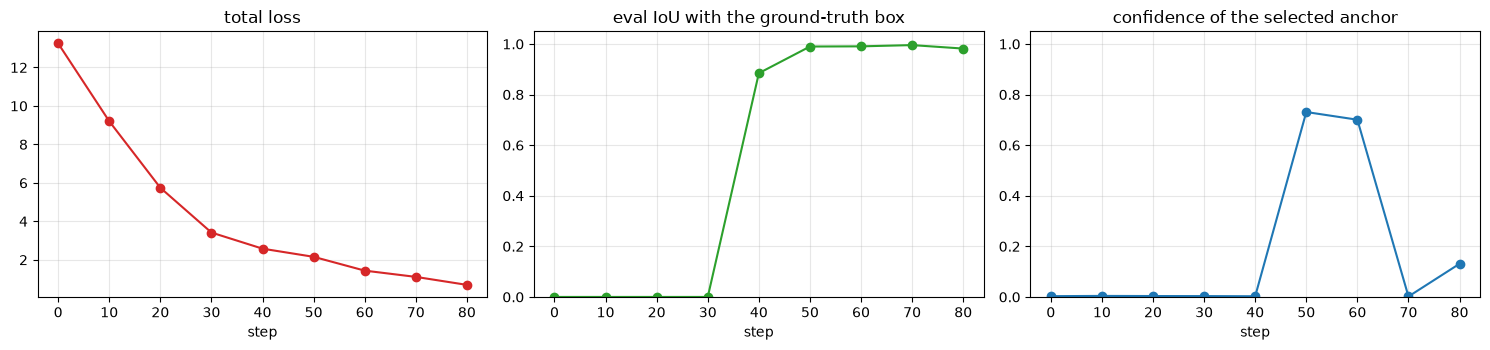

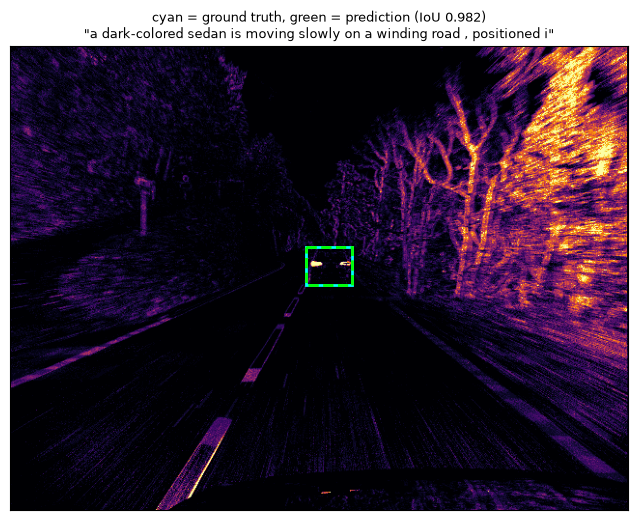

In [10]:
steps, losses, ious, scores = map(np.array, zip(*hist))
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(steps, losses, "o-", color="tab:red"); ax[0].set_title("total loss")
ax[1].plot(steps, ious, "o-", color="tab:green"); ax[1].set_ylim(0, 1.05)
ax[1].set_title("eval IoU with the ground-truth box")
ax[2].plot(steps, scores, "o-", color="tab:blue"); ax[2].set_ylim(0, 1.05)
ax[2].set_title("confidence of the selected anchor")
for a in ax:
    a.set_xlabel("step"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

fit.eval()
with torch.no_grad():
    box, score = fit.predict(cube, ids, am)
frame = cube[:, 0].sum((0, 1)).cpu()
plt.figure(figsize=(7, 5.3))
plt.imshow(frame, cmap="inferno", vmax=np.percentile(frame, 99.5))
x0, y0, x1, y1 = gt[0].cpu().tolist()
plt.gca().add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="cyan", lw=2))
px0, py0, px1, py1 = box[0].cpu().tolist()
plt.gca().add_patch(plt.Rectangle((px0, py0), px1 - px0, py1 - py0,
                                  fill=False, ec="lime", lw=2, ls="--"))
plt.title(f"cyan = ground truth, green = prediction (IoU {box_iou(box, gt)[0,0]:.3f})\n"
          f'"{tgt["caption"][:70]}"', fontsize=9)
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()
del fit, fit_crit, opt; gc.collect(); torch.cuda.empty_cache()

## 7. Cost knobs

`fuse_scales` is the lever that matters. Cross-attention is linear in the query count --
CMSF forms `k^T v` (256x256) before touching `q`, which is the only reason a dense feature
map is affordable at all -- but the stride-4 tap is still 19200 query tokens, four times
the stride-8 map, and it feeds CMSF's gated MLP. Dropping it from fusion leaves stride 4
to pick up language through the neck's top-down path instead.

In [11]:
# free everything this notebook is still holding, or it counts against every peak below
for _name in ("model", "crit", "out", "loss", "parts", "maps", "probe_cube", "raw", "rerun"):
    globals().pop(_name, None)
gc.collect(); torch.cuda.empty_cache()
BASELINE = torch.cuda.memory_allocated() / 2**30
print(f"resident before measuring: {BASELINE:.2f} GiB\n")


def cost(fuse, hw=(480, 640)):
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    torch.manual_seed(0)
    with quiet():
        m = SpikeTransDVG(num_classes=1, T=T_STEPS, freeze_vision=True,
                          vision_ckpt=str(VISION_CKPT), fuse_scales=fuse).to(DEVICE)
    c = GroundingDetectionLoss(m).to(DEVICE); m.train()
    cu = (torch.rand(T_STEPS, 1, 2, *hw, device=DEVICE) * 4).round()
    torch.cuda.synchronize(); t0 = time.time()
    l, _ = c(m(cu, ids, am), gt); l.backward()
    torch.cuda.synchronize()
    r = (torch.cuda.max_memory_allocated() / 2**30 - BASELINE, time.time() - t0,
         sum(p.numel() for p in m.fusion.parameters()) / 1e6)
    del m, c, cu, l; gc.collect(); torch.cuda.empty_cache()
    return r

print(f"{'fused scales':22s} {'peak GiB':>9s} {'fwd+bwd':>9s} {'fusion params':>14s}")
for label, fs in [("all three", None), ("s8 + s16b", ("s8", "s16b")), ("s16b only", ("s16b",))]:
    mem, dt, pr = cost(fs)
    print(f"{label:22s} {mem:9.2f} {dt:8.2f}s {pr:13.2f}M")

resident before measuring: 6.14 GiB

fused scales            peak GiB   fwd+bwd  fusion params


[W822 21:27:55.943027245 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 796917760 bytes (free: 734658560, total: 33623638016).


all three                  21.67     0.39s          2.25M


s8 + s16b                  17.96     0.34s          1.59M


s16b only                  17.02     0.33s          0.93M


## Notes for the training run

* **Batch size 1 at 480x640**, on a 32 GiB card, with `freeze_vision=True`. The backbone
  under `no_grad` is the difference between running and an OOM; `EventVisionEncoder`
  documents 16 GiB for a *trainable* backbone at B=1 before any of this is attached.
  Gradient checkpointing is deliberately unavailable -- recomputation would re-run
  stateful LIF neurons whose membranes have already advanced.
* **Call `calibrate_bn` before the first eval** of a fresh model, or the eval path returns
  zeros and every caption predicts the same box.
* **`attn_bn_gain=1.0` silently disables the text branch.** If a grounding result looks
  suspiciously like plain detection, check this first.
* **`num_classes=1`** is grounding; `num_classes=8` with `gt_labels` turns the same model
  into language-conditioned detection.
* **Neither encoder is spike-pretrained.** The vision weights are Meta-SpikeFormer's
  ImageNet checkpoint and the text weights are roberta-base transplanted into SpikeLM's
  architecture -- both ANN-trained, adapted to the spiking regime here rather than
  inheriting it. That is a property of the SNN literature, not of this wiring, and it
  belongs in any writeup.
* **The finest tap is the expensive one.** Start with `fuse_scales=("s8", "s16b")` if
  memory is tight; it costs 3.7 GiB less and runs ~2.5x faster per step.